# Brain tumor MRI classification — reproducible capstone experiments
**Disci, Gurcan & Soylu (2025), Cancers 17(1), 121**  
**Team:** Vishesh Rao, Pranay Vishwakarma, Manu Vahan · **M2/M3:** 6 October 2026

This notebook uses the shared repository pipeline and displays **actual completed runs**. Published reference values, smoke checks, and measured results are kept separate. It defaults to analysis of saved results, so the presentation does not start a long training job.

### Introduction and hypothesis
Transfer learning offers a practical four-class MRI classifier under limited compute. Our literature survey emphasizes class-sensitive performance, computational cost, and evaluation reliability. We reproduce the paper's standard CNN comparison and separately audit known train/test duplicates. Image-level results cannot establish generalization to unseen patients without subject identifiers.

**Operational hypothesis:** Under an identical leakage-audited protocol, MobileNetV2's test macro-F1 is no more than **0.02 below Xception's**, with fewer total model parameters. This is a preliminary single-seed comparison, not a statistical non-inferiority claim.

[Paper](https://doi.org/10.3390/cancers17010121) · [Exact dataset version 1](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/1)

### Local / free Colab setup
Locally, open this notebook from the repository using its Python 3.11/3.12 environment. For Colab, select a GPU runtime and upload **brain_mri_colab.zip** to `/content` using the Files sidebar. The next cell extracts our code bundle and installs the pinned dependencies only in Colab. MRI images and heavy checkpoints are downloaded/generated separately. If dependencies were already imported in Colab before installation, restart the runtime before continuing.

In [2]:
import os
import sys
import json
from pathlib import Path

IN_COLAB = Path('/content').exists() and 'google.colab' in sys.modules
if IN_COLAB:
    import subprocess
    from zipfile import ZipFile
    bundle = Path('/content/brain_mri_colab.zip')
    root = Path('/content/brain_mri')
    if not (root / 'configs/disci2025.yaml').exists():
        if not bundle.exists():
            raise FileNotFoundError('Upload brain_mri_colab.zip to the Colab Files sidebar first.')
        with ZipFile(bundle) as archive:
            for member in archive.infolist():
                if not (root / member.filename).resolve().is_relative_to(root.resolve()):
                    raise ValueError('Unsafe bundle path')
            archive.extractall(root)
    try:
        # Run pip and capture stdout/stderr to print the exact error message on failure
        subprocess.run(
            [sys.executable, '-m', 'pip', 'install', '-r', str(root / 'requirements.txt')],
            check=True,
            capture_output=True,
            text=True
        )
    except subprocess.CalledProcessError as e:
        print("--- PIP INSTALLATION FAILED ---")
        print("STDOUT:\n", e.stdout)
        print("STDERR:\n", e.stderr)
        raise e
    ROOT = root
else:
    candidates = [Path.cwd(), *Path.cwd().parents]
    ROOT = next((p for p in candidates if (p / 'configs/disci2025.yaml').exists()), None)
    if ROOT is None:
        raise FileNotFoundError('Open the notebook from the extracted project/repository folder.')
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
os.environ.setdefault('KERAS_HOME', str(ROOT / '.cache/keras'))
os.environ.setdefault('MPLCONFIGDIR', str(ROOT / '.cache/matplotlib'))
os.environ.setdefault('XDG_CACHE_HOME', str(ROOT / '.cache'))
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
print('Project:', ROOT)
print('Mode:', 'Colab' if IN_COLAB else 'local')

Project: /content/brain_mri
Mode: Colab


## 1. Settings and experiment identity
The paper reports **128 × 128 × 3**, Adam **0.0001**, batch **20**, **five epochs**, and a common Flatten → Dropout(0.3) → Dense(128, ReLU) → Dropout(0.2) → Softmax(4) head. Seed 42, Gaussian kernel 5, threshold 45, bounding-rectangle crop, and full backbone fine-tuning are disclosed assumptions.

`paper_based` preserves the official split and reports clean and seeded transformed test views. `leakage_audited` removes exact overlap and redundant training images, uses 15% validation, and augments training only. Perceptual candidates remain unresolved; no patient independence is asserted.

The optional all-model switch adds the other four paper backbones. Changing normalization, trainability, sample counts, or epochs is a **different experiment**, not an exact reproduction.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image
from src.reproduction.config import load_config, CLASSES
from src.reproduction.training import configure_runtime
from src.reproduction.evaluation import PAPER, classification_metrics
from src.reproduction.artifacts import paired_experiment_identity
from scripts.reproduce_disci2025 import download_dataset, prepare, refresh_results

CONFIG = load_config(ROOT / 'configs/disci2025.yaml')
CONFIG['data_dir'] = str(ROOT / 'data/raw')
CONFIG['output_dir'] = str(ROOT / 'outputs/disci2025')
RUN_TRAINING = True
RUN_ALL_PAPER_MODELS = False
MODELS = ['MobileNetV2', 'Xception']

analysis_environment = configure_runtime(CONFIG['seed'], ROOT / '.cache')
assert any('GPU' in device for device in analysis_environment['devices']), 'Select T4 GPU before full training.'
display(pd.Series(CONFIG, name='experiment settings'))
print('Notebook analysis devices:', analysis_environment['devices'])
print('Training hardware and versions are recorded separately in each run provenance.')

dataset                         masoudnickparvar/brain-tumor-mri-dataset
dataset_version                                                        1
data_dir                                     /content/brain_mri/data/raw
output_dir                          /content/brain_mri/outputs/disci2025
seed                                                                  42
protocol                                                     paper_based
class_names                    [glioma, meningioma, no_tumor, pituitary]
models                 [MobileNetV2, Xception, InceptionV3, ResNet50,...
image_size                                                           128
batch_size                                                            20
epochs                                                                 5
learning_rate                                                     0.0001
blur_kernel                                                            5
threshold                                          

Notebook analysis devices: ["PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')", "PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')"]
Training hardware and versions are recorded separately in each run provenance.


## 2. Exact dataset and leakage audit
**Pin version 1.** The current version 2 has 7,200 images and does not match the paper's 7,023. All eight class/partition counts are checked before training. The archive checksum and public source are included in the deliverable.

Exact decoded-pixel hashes identify duplicated content independently of filenames. Perceptual hashes only propose pairs for review; they do not identify patients.

In [5]:
source = json.loads((ROOT / 'results/disci2025/dataset_source.json').read_text())
audit = json.loads((ROOT / 'results/disci2025/data_audit.json').read_text())
counts = pd.DataFrame({'class': CLASSES, 'Training': [1321, 1339, 1595, 1457], 'Testing': [300, 306, 405, 300]})
display(counts)
print('Dataset:', source['dataset'], 'version', source['version'])
print('Archive SHA256:', source['archive_sha256'])
display(pd.Series({k: audit[k] for k in ['cross_split_exact_count', 'within_train_exact_redundant_count', 'within_test_exact_redundant_count', 'patient_ids_available']}, name='audit'))
print('Unreviewed perceptual candidate pairs:', len(audit['near_duplicate_candidates']))
print('Known cross-split duplicate images are excluded only in the separate audited protocol.')

,class,Training,Testing
0,glioma,1321,300
1,meningioma,1339,306
2,no_tumor,1595,405
3,pituitary,1457,300


Dataset: masoudnickparvar/brain-tumor-mri-dataset version 1
Archive SHA256: 048b7413ce05bb52627046cfa5cde097b12e865aa80f6110959f547fd6fe4ef1


cross_split_exact_count                 263
within_train_exact_redundant_count      207
within_test_exact_redundant_count        30
patient_ids_available                 False
Name: audit, dtype: object

Unreviewed perceptual candidate pairs: 1254
Known cross-split duplicate images are excluded only in the separate audited protocol.


## 3. Preprocessing example
Largest-contour cropping extracts foreground, which may be the brain rather than a tumor. A missing contour falls back to the full slice. No lesion segmentation claim is made. Raw examples are displayed only when MRI files are available; the Colab bundle keeps the measured-result evidence but excludes the large dataset.

In [6]:
from src.reproduction.data import inventory_dataset
from src.reproduction.preprocessing import preprocess_image
import cv2

if (Path(CONFIG['data_dir']) / 'Training').exists():
    inventory = inventory_dataset(CONFIG['data_dir'])
    examples = inventory[inventory.original_partition == 'train'].groupby('label').head(1)
    fig, axes = plt.subplots(4, 2, figsize=(7, 10))
    for row, item in enumerate(examples.itertuples()):
        path = Path(CONFIG['data_dir']) / item.path
        original = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        processed, info = preprocess_image(path, CONFIG)
        axes[row, 0].imshow(original, cmap='gray')
        axes[row, 0].set_title(item.class_name + ' · original')
        axes[row, 1].imshow(processed)
        axes[row, 1].set_title('Foreground crop · 128 × 128')
        for axis in axes[row]: axis.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('Raw images are not bundled. Set RUN_TRAINING=True to download them before new experiments.')

Raw images are not bundled. Set RUN_TRAINING=True to download them before new experiments.


## 4. Optional training — explicitly enabled
Keep `RUN_TRAINING=False` for the evaluation presentation. For a new Colab run, enable it in section 1. This trains the two hypothesis models first under both protocols. Enable `RUN_ALL_PAPER_MODELS` to run the additional four backbones afterward. Final checkpoints are used, with no test-set model selection. A completed run is reused only when its data/configuration identity and required artifacts agree.

In [7]:
if RUN_TRAINING:
    from src.reproduction.training import train_model
    if not (Path(CONFIG['data_dir']) / 'Training').exists():
        download_dataset(Path(CONFIG['data_dir']))
    for protocol in ['paper_based', 'leakage_audited']:
        config = {**CONFIG, 'protocol': protocol}
        manifests = prepare(config)
        for model_name in MODELS:
            run_dir = Path(config['output_dir']) / protocol / model_name
            train_model(model_name, manifests, config, run_dir, resume=True)
            refresh_results(Path(config['output_dir']))
    if RUN_ALL_PAPER_MODELS:
        config = {**CONFIG, 'protocol': 'paper_based'}
        manifests = prepare(config)
        # for model_name in ['InceptionV3', 'ResNet50', 'VGG16', 'DenseNet121']:
        #     train_model(model_name, manifests, config, Path(config['output_dir']) / 'paper_based' / model_name, resume=True)
        #     refresh_results(Path(config['output_dir']))
else:
    print('Training disabled: analyzing saved results only. Smoke runs are excluded.')

Counts: {'train': 5712, 'test': 1311}; exact train/test overlap: 263; unreviewed near-match pairs: 1254
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2: 5712 training images; 4,880,068 parameters; 5 epochs; devices=["PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')", "PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')"]
Epoch 1/5
286/286 - 69s - 241ms/step - accuracy: 0.8265 - loss: 0.4887
Epoch 2/5
286/286 - 31s - 107ms/step - accuracy: 0.9277 - loss: 0.1934
Epoch 3/5
286/286 - 31s - 107ms/step - accuracy: 0.9550 - loss: 0.1227
Epoch 4/5
286/286 - 32s - 111ms/step - accuracy: 0.9702 - loss: 0.0798
Epoch 5/5
286/286 - 30s - 106ms/step - accuracy: 0.9792 - loss: 0.0533
MobileNetV2: clean test accuracy=0.7208, macro-F1=0.6798
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Xception: 5712 training images; 25,056,428 parameters; 5 epochs; devices=["PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')", "PhysicalDevice(name='/physica

## 5. Published targets and measured results
**Important correction:** Xception's published testing accuracy is **95.27%**. The headline **98.73%** is consistent with a sample-count-weighted combination of training and test accuracy. It is not a held-out metric. The formula is inferred from the tables; source inconsistencies are retained rather than forced into agreement.

The reference table below contains source values. The next table contains actual completed MRI runs. Differences are in percentage points and retain each protocol and test view.

In [8]:
display(PAPER.round(4))
refresh_results(Path(CONFIG['output_dir']))
summary_path = ROOT / 'results/disci2025/summary.csv'
summary = pd.read_csv(summary_path) if summary_path.exists() and summary_path.stat().st_size > 2 else pd.DataFrame()
if summary.empty:
    print('No accepted full experiment results yet. This notebook does not fabricate reproduced scores.')
else:
    columns = ['model', 'protocol', 'evaluation_view', 'n_train', 'n_test', 'epochs',
               'accuracy', 'macro_f1', 'weighted_f1', 'balanced_accuracy', 'macro_roc_auc',
               'test_accuracy_difference_pp']
    display(summary[columns].round(4))
    completed = set(summary.loc[summary.protocol == 'paper_based', 'model'])
    display(pd.DataFrame({'paper model': CONFIG['models'], 'full paper-based run completed': [m in completed for m in CONFIG['models']]}))

,model,paper_train_accuracy,paper_test_accuracy,paper_macro_f1,paper_weighted_f1,paper_combined_accuracy
0,Xception,0.9952,0.9527,0.9491,0.9529,0.9873
1,MobileNetV2,0.9898,0.9451,0.9411,0.9457,0.9815
2,InceptionV3,0.9810,0.9451,0.9409,0.9452,0.9743
3,ResNet50,0.9897,0.9062,0.9010,0.9045,0.9741
4,VGG16,0.9721,0.9504,0.9470,0.9478,0.9680
5,DenseNet121,0.9652,0.9285,0.9220,0.9265,0.9583


,model,protocol,evaluation_view,n_train,n_test,epochs,accuracy,macro_f1,weighted_f1,balanced_accuracy,macro_roc_auc,test_accuracy_difference_pp
0,MobileNetV2,leakage_audited,clean,4518,1311,5,0.7429,0.7372,0.7391,0.7225,0.9377,-20.2156
1,Xception,leakage_audited,clean,4518,1311,5,0.9176,0.9176,0.9176,0.9204,0.9868,-3.5080
2,MobileNetV2,paper_based,clean,5712,1311,5,0.7208,0.6798,0.6941,0.6966,0.9578,-22.4276
3,MobileNetV2,paper_based,transformed,5712,1311,5,0.7117,0.6691,0.6841,0.6864,0.9551,-23.3430
4,Xception,paper_based,clean,5712,1311,5,0.9367,0.9354,0.9369,0.9348,0.9901,-1.6010
5,Xception,paper_based,transformed,5712,1311,5,0.9329,0.9315,0.9331,0.9307,0.9905,-1.9824


,paper model,full paper-based run completed
0,MobileNetV2,True
1,Xception,True
2,InceptionV3,False
3,ResNet50,False
4,VGG16,False
5,DenseNet121,False


## 6. Learning curves and confusion matrices
These figures are generated from saved histories and clean held-out predictions, not copied from the paper. Learning curves show training and diagnostic validation only; test accuracy is not used to select a model.

leakage_audited · MobileNetV2


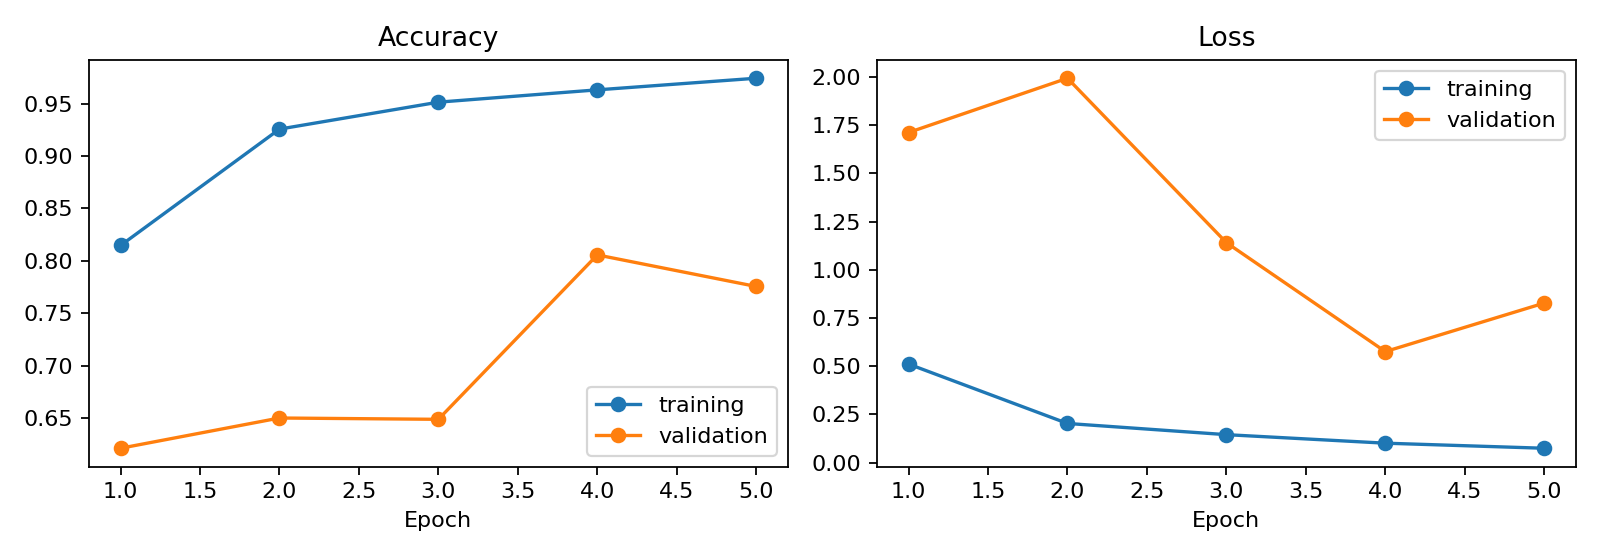

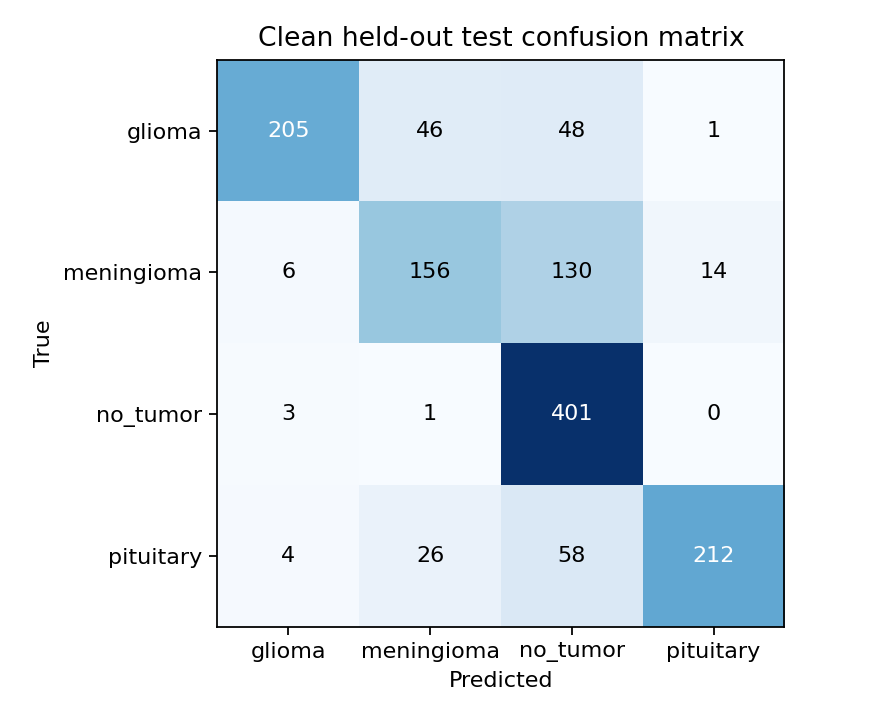

leakage_audited · Xception


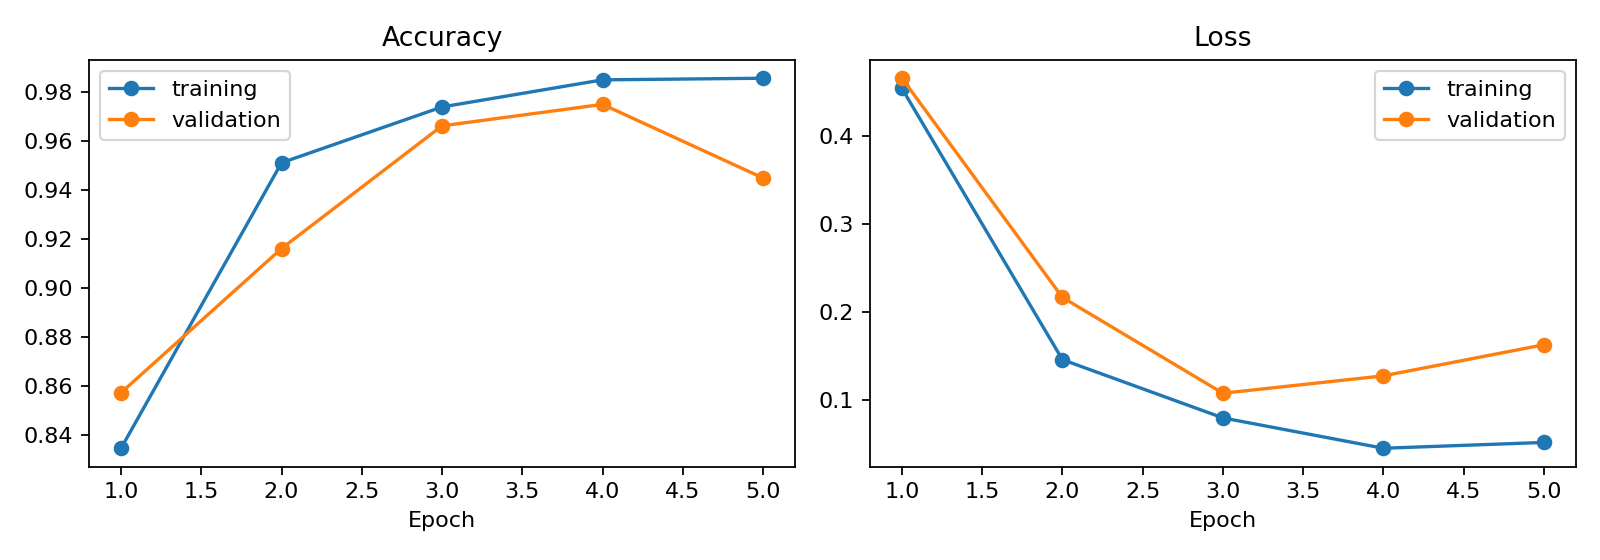

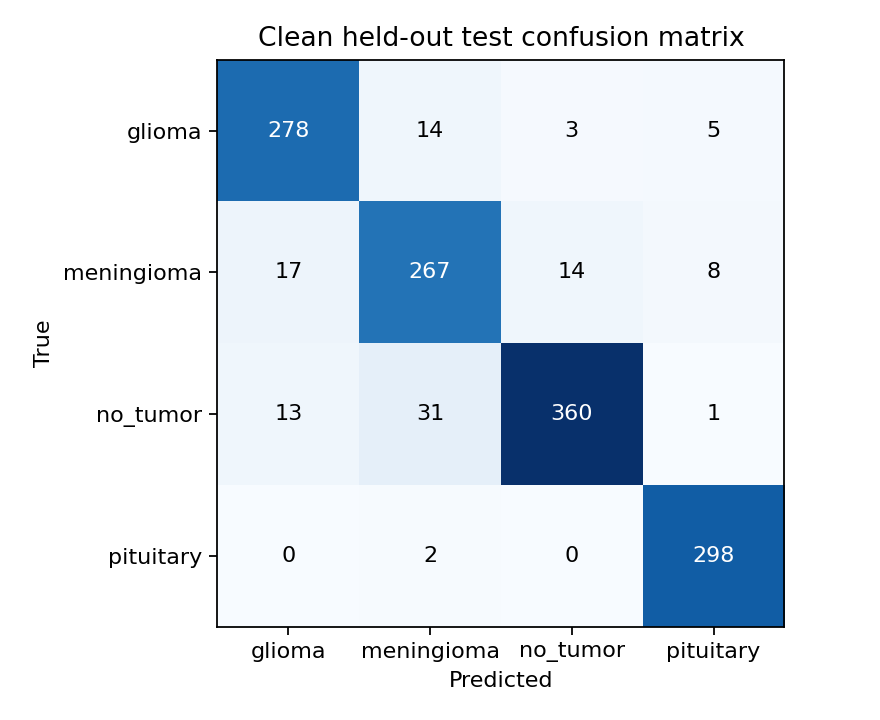

paper_based · MobileNetV2


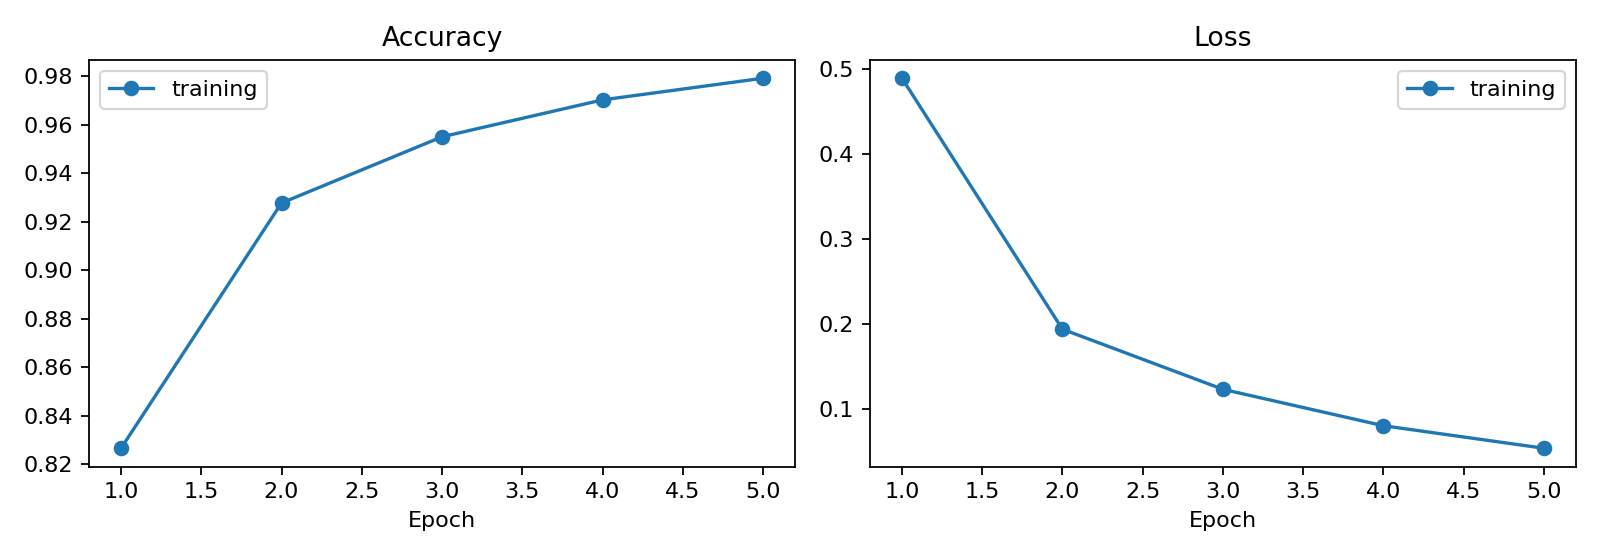

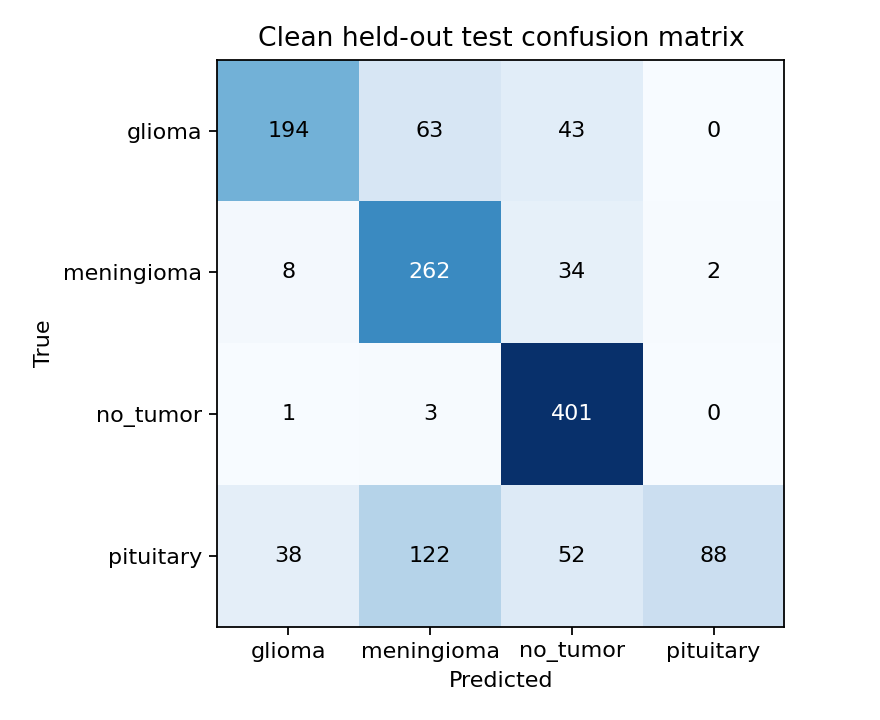

paper_based · Xception


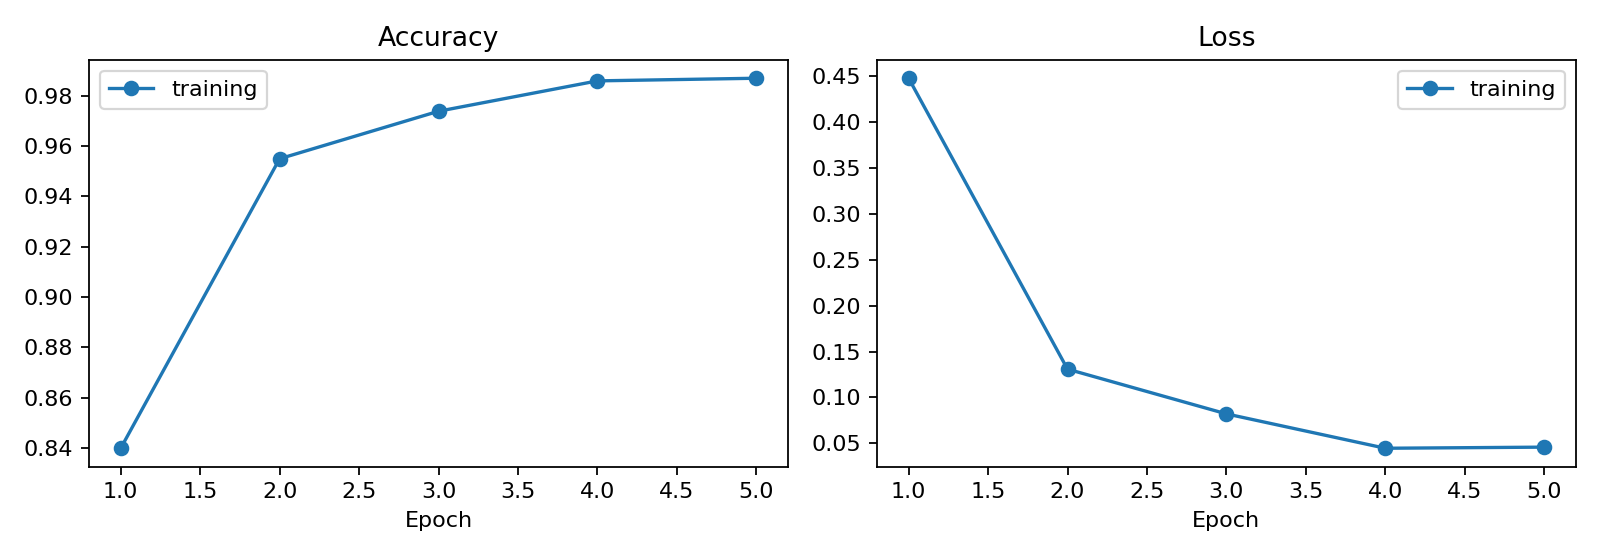

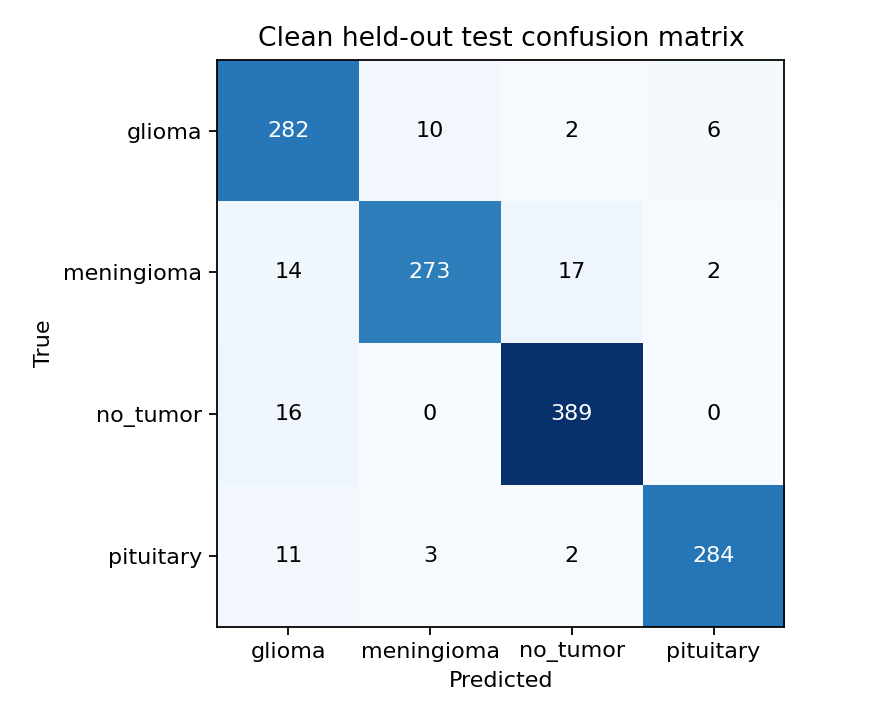

In [9]:
if not summary.empty:
    for row in summary[summary.evaluation_view == 'clean'].itertuples():
        folder = Path(CONFIG['output_dir']) / row.run_dir
        print(row.protocol, '·', row.model)
        for filename in ['learning_curves.png', 'confusion_matrix.png']:
            if (folder / filename).exists(): display(Image(filename=str(folder / filename), width=700))

## 7. Verify metrics from saved predictions
We recompute macro-F1 and accuracy from exported probabilities, and check all 1,311 official test images are represented. This protects against misordered labels and hand-entered result tables. The duplicate test images remain disclosed.

In [10]:
if not summary.empty:
    verification = []
    for row in summary.itertuples():
        path = Path(CONFIG['output_dir']) / row.run_dir / f'predictions_{row.evaluation_view}.csv'
        saved = pd.read_csv(path)
        probabilities = saved[[f'p_{name}' for name in CLASSES]].to_numpy()
        metrics = classification_metrics(saved.label.to_numpy(), probabilities)
        assert len(saved) == row.n_test == 1311
        assert np.isclose(metrics['accuracy'], row.accuracy)
        assert np.isclose(metrics['macro_f1'], row.macro_f1)
        verification.append({'model': row.model, 'protocol': row.protocol, 'view': row.evaluation_view,
                             'prediction rows': len(saved), 'recomputed metrics match': True})
    display(pd.DataFrame(verification))

,model,protocol,view,prediction rows,recomputed metrics match
0,MobileNetV2,leakage_audited,clean,1311,True
1,Xception,leakage_audited,clean,1311,True
2,MobileNetV2,paper_based,clean,1311,True
3,MobileNetV2,paper_based,transformed,1311,True
4,Xception,paper_based,clean,1311,True
5,Xception,paper_based,transformed,1311,True


## 8. Resource comparison and hypothesis outcome
Counts include the head. Training time excludes data/weight downloads and final evaluation. Inference timing, when available, uses warmed-up batch-1 execution on the same device and excludes preprocessing. Single-seed outcomes are preliminary.

In [11]:
if not summary.empty:
    resource_columns = ['model', 'protocol', 'total_parameters', 'training_seconds']
    for column in ['median_inference_ms', 'p95_inference_ms']:
        if column in summary: resource_columns.append(column)
    display(summary[summary.evaluation_view == 'clean'][resource_columns].round(3))
    pair = summary[(summary.protocol == 'leakage_audited') & (summary.evaluation_view == 'clean')].set_index('model')
    if {'MobileNetV2', 'Xception'}.issubset(pair.index):
        mobile, xception = pair.loc['MobileNetV2'], pair.loc['Xception']
        provenance = json.loads((ROOT / 'results/disci2025/provenance.json').read_text())['runs']
        identities = {r['model']: r for r in provenance if r['protocol'] == 'leakage_audited'}
        assert paired_experiment_identity(identities['MobileNetV2'], identities['Xception']), 'Different data or shared settings: no paired conclusion'
        assert mobile.n_train == xception.n_train
        assert mobile.epochs == xception.epochs == 5
        assert mobile.seed == xception.seed
        gap = float(xception.macro_f1 - mobile.macro_f1)
        supported = gap <= .02 and mobile.total_parameters < xception.total_parameters
        display(pd.Series({'Xception minus MobileNetV2 macro-F1': gap,
                           'allowed margin': .02,
                           'MobileNetV2 uses fewer total parameters': bool(mobile.total_parameters < xception.total_parameters),
                           'hypothesis supported in this single-seed experiment': bool(supported)}))
    else:
        print('Hypothesis outcome pending: both full audited model runs are required.')

,model,protocol,total_parameters,training_seconds,median_inference_ms,p95_inference_ms
0,MobileNetV2,leakage_audited,4880068,179.381,5.318,6.448
1,Xception,leakage_audited,25056428,239.165,10.021,10.323
2,MobileNetV2,paper_based,4880068,192.402,5.322,5.854
4,Xception,paper_based,25056428,346.790,6.026,6.242


Xception minus MobileNetV2 macro-F1                    0.180356
allowed margin                                             0.02
MobileNetV2 uses fewer total parameters                    True
hypothesis supported in this single-seed experiment       False
dtype: object

## 9. Conclusions and presentation boundaries
- Explain the correct dataset **version**, the actual completed runs, and ordinary held-out metrics.
- Explain the **263 exact overlapping training images** and how the audited protocol removes them.
- Interpret our lightweight-model hypothesis using the actual paired results; report an unfavorable result if obtained.
- Keep the paper's combined train/test statistic separate from accuracy on unseen images.
- Do not claim exact numerical replication, patient-independent generalization, validated tumor localization, clinical validity, or completion of models marked pending.

**Limitations:** underspecified paper preprocessing/trainability; GPU/library differences; one seed; missing patient IDs; unresolved perceptual candidates; duplicate test images; several changes between original and audited protocols. Future work includes repeated seeds, grouped/external validation, class-weighting or normalization ablations, and annotation-based explanations.

**Report:** `docs/report/Disci2025_Reproduction_Addendum.md` contains the introduction, hypothesis, methods, audit, measured results and limitations. The original literature-survey PDF is preserved.

In [12]:
if IN_COLAB and RUN_TRAINING:
    import zipfile
    from google.colab import files
    archive = Path('/content/disci2025_results.zip')
    with zipfile.ZipFile(archive, 'w', zipfile.ZIP_DEFLATED) as target:
        for directory in ['results/disci2025', 'outputs/disci2025']:
            for path in (ROOT / directory).rglob('*'):
                if path.is_file() and path.suffix in {'.json', '.csv', '.png'}:
                    target.write(path, path.relative_to(ROOT))
    files.download(str(archive))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>